# Monte Carlo Pricing of European and Binary Call Options

## Introduction
This project studies the pricing of European call and binary call options using Monte Carlo simulation under the risk-neutral measure. The underlying stock price is assumed to follow the geometric Brownian motion

$$
dS_t = rS_tdt + \sigma S_tdW_t.
$$

Under the risk-neutral valuation framework, the value of a derivative can be written as the discounted expected payoff:

$$
V(S,t)=e^{-r(T-t)}E^Q[\text{Payoff}].
$$

The project compares three simulation schemes for the underlying stock price: the exact closed-form time-stepping scheme, the Euler-Maruyama scheme, and the Milstein scheme. The simulated terminal stock prices are used to price both a European call option and a cash-or-nothing binary call option. Analytical Black-Scholes prices are used as benchmarks for error analysis.

The project also investigates how changes in model parameters affect option prices, and examines the antithetic variates method as a variance reduction technique for Monte Carlo simulation.

### Course material connection

This project is based on Section 3.1 for the Black-Scholes model and analytical European call pricing, Section 3.2 for the risk-neutral valuation framework, Section 3.4 for Monte Carlo simulation and Euler discretization, T5 for Monte Carlo techniques and variance reduction, and the Python 9 Monte Carlo lab for implementation style and simulation-based option pricing.


## Step 1. Baseline model and analytical benchmark

This project prices European call and binary call options using Monte Carlo simulation under the risk-neutral measure. The underlying stock price is assumed to follow the geometric Brownian motion

$$
dS_t = rS_tdt + \sigma S_tdW_t,
$$

where \(r\) is the continuously compounded risk-free rate and \(\sigma\) is the annual volatility. Under this model, the terminal stock price has the closed-form solution

$$
S_T = S_0 \exp\left[\left(r-\frac{1}{2}\sigma^2\right)T+\sigma\sqrt{T}Z\right],
\quad Z\sim N(0,1).
$$

As a benchmark, the Black-Scholes analytical price is used for the European call option. For the binary call option, a cash-or-nothing payoff is assumed, paying 1 if \(S_T>K\) and 0 otherwise. The analytical binary call price is therefore

$$
e^{-rT}N(d_2).
$$

This benchmark will be used later to evaluate the numerical errors of the Euler-Maruyama, Milstein and closed-form simulation schemes.

### Course material connection

This step is mainly related to Section 3.1, where the Black-Scholes model and the analytical European call option formula are introduced. The risk-neutral valuation idea is linked to Section 3.2, where option prices are expressed as discounted expected payoffs under the risk-neutral measure. The implementation style is also connected to the Python 8 Black-Scholes lab, where analytical option pricing functions are constructed in Python.

In [ ]:
# ==============================
# Benchmark model, analytical prices, and closed-form GBM Monte Carlo
# ==============================

# Import libraries
import numpy as np
import pandas as pd
from scipy.stats import norm

In [ ]:
# Set random seed to ensure reproducibility
np.random.seed(42)

In [ ]:
# ==============================
# Define option input parameters
# ==============================

S0 = 100       # Current stock price
K = 100        # Strike price
T = 1.0        # Time to maturity in years
r = 0.05       # Continuously compounded risk-free interest rate
sigma = 0.20   # Annualized volatility

n_paths = 100000   # Number of Monte Carlo simulation paths

In [ ]:
# ==============================
# Analytical benchmark functions
# ==============================

def bs_d1_d2(S0, K, T, r, sigma):
    """
    Calculate d1 and d2 in the Black-Scholes formula.
    """
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2


def bs_european_call_price(S0, K, T, r, sigma):
    """
    Black-Scholes analytical price for a European call option.

    Payoff = max(S_T - K, 0)
    """
    d1, d2 = bs_d1_d2(S0, K, T, r, sigma)
    call_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price


def bs_binary_call_price(S0, K, T, r, sigma, cash_payoff=1.0):
    """
    Analytical price for a cash-or-nothing binary call option.

    Payoff = cash_payoff, if S_T > K
           = 0, otherwise
    """
    d1, d2 = bs_d1_d2(S0, K, T, r, sigma)
    binary_price = cash_payoff * np.exp(-r * T) * norm.cdf(d2)
    return binary_price

In [ ]:
# Compute analytical benchmark prices
analytical_call = bs_european_call_price(S0, K, T, r, sigma)
analytical_binary = bs_binary_call_price(S0, K, T, r, sigma)

print("Analytical European Call Price:", analytical_call)
print("Analytical Binary Call Price:", analytical_binary)

Analytical European Call Price: 10.450583572185565
Analytical Binary Call Price: 0.5323248154537634


In [ ]:
# ==============================
# Closed-form GBM simulation
# ==============================

def simulate_terminal_stock_closed_form(S0, T, r, sigma, n_paths, random_seed=42):
    """
    Simulate terminal value S_T directly using the closed-form GBM solution.

    S_T = S0 * exp((r - 0.5*sigma^2)*T + sigma*sqrt(T)*Z)
    """
    rng = np.random.default_rng(random_seed)
    Z = rng.standard_normal(n_paths)

    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    return ST


def monte_carlo_price_from_terminal(ST, K, T, r, option_type="european_call", cash_payoff=1.0):
    """
    Calculate Monte Carlo option price and standard error based on simulated terminal values S_T.

    option_type:
    - "european_call": European call option
    - "binary_call": Binary call option, cash-or-nothing
    """
    if option_type == "european_call":
        payoff = np.maximum(ST - K, 0)
    elif option_type == "binary_call":
        payoff = cash_payoff * (ST > K)
    else:
        raise ValueError("option_type must be 'european_call' or 'binary_call'")

    discount_factor = np.exp(-r * T)

    price = discount_factor * np.mean(payoff)

    # Monte Carlo standard error
    standard_error = discount_factor * np.std(payoff, ddof=1) / np.sqrt(len(payoff))

    return price, standard_error


In [ ]:
# Simulate terminal values
ST_closed = simulate_terminal_stock_closed_form(
    S0=S0,
    T=T,
    r=r,
    sigma=sigma,
    n_paths=n_paths,
    random_seed=42
)

# Price European call and binary call using simulated terminal values
mc_call_closed, se_call_closed = monte_carlo_price_from_terminal(
    ST=ST_closed,
    K=K,
    T=T,
    r=r,
    option_type="european_call"
)

mc_binary_closed, se_binary_closed = monte_carlo_price_from_terminal(
    ST=ST_closed,
    K=K,
    T=T,
    r=r,
    option_type="binary_call",
    cash_payoff=1.0
)

In [ ]:
# Summarize results
summary_step1 = pd.DataFrame({
    "Option": ["European Call", "Binary Call"],
    "Analytical Price": [analytical_call, analytical_binary],
    "Closed-form MC Price": [mc_call_closed, mc_binary_closed],
    "MC Standard Error": [se_call_closed, se_binary_closed],
    "MC Error": [mc_call_closed - analytical_call, mc_binary_closed - analytical_binary],
    "Absolute Error": [abs(mc_call_closed - analytical_call), abs(mc_binary_closed - analytical_binary)]
})

summary_step1

,Option,Analytical Price,Closed-form MC Price,MC Standard Error,MC Error,Absolute Error
0,European Call,10.450584,10.420541,0.046770,-0.030042,0.030042
1,Binary Call,0.532325,0.530310,0.001494,-0.002014,0.002014


## Step 2. Simulation schemes for the underlying stock price


In this step, three schemes are implemented to simulate the underlying stock price under the risk-neutral geometric Brownian motion:

$$
dS_t = rS_tdt + \sigma S_tdW_t.
$$

The first method is the exact closed-form time-stepping solution:

$$
S_{t+\Delta t}
=
S_t \exp\left[
\left(r-\frac{1}{2}\sigma^2\right)\Delta t
+\sigma\sqrt{\Delta t}Z
\right].
$$

The second method is the Euler-Maruyama scheme:

$$
S_{t+\Delta t}
=
S_t
\left[
1+r\Delta t+\sigma\sqrt{\Delta t}Z
\right].
$$

The third method is the Milstein scheme:

$$
S_{t+\Delta t}
=
S_t
\left[
1+r\Delta t+\sigma\sqrt{\Delta t}Z
+
\frac{1}{2}\sigma^2(Z^2-1)\Delta t
\right].
$$

The Milstein method adds a stochastic correction term to improve the approximation accuracy. In each time step, the same random number \(Z\) is used in both the diffusion term and the Milstein correction term. To make the comparison fair, the same random numbers are used across the three simulation schemes.

### Course material connection

This step is mainly related to Section 3.4, where the Euler discretization and the exact lognormal time-stepping formula for the risk-neutral stock price process are introduced. It is also connected to the Python 9 Monte Carlo lab, where simulated asset paths are used to price European options. The risk-neutral pricing idea is linked to Section 3.2, while later variance reduction analysis will be related to T5 and the Python 9 lab.

In [ ]:
# ==============================
# Simulation schemes
# ==============================

def generate_random_numbers(n_paths, n_steps, random_seed=42):
    """
    Generate standard normal random numbers for Monte Carlo simulation.

    The same random numbers can be used across different schemes
    to make the comparison fair.
    """
    rng = np.random.default_rng(random_seed)
    Z = rng.standard_normal((n_paths, n_steps))
    return Z
def simulate_stock_paths_closed_form(S0, T, r, sigma, Z):
    """
    Simulate stock paths using the exact GBM time-stepping formula.
    """
    n_paths, n_steps = Z.shape
    dt = T / n_steps

    S = np.full(n_paths, S0, dtype=float)

    for j in range(n_steps):
        S = S * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, j])

    return S


def simulate_stock_paths_euler(S0, T, r, sigma, Z):
    """
    Simulate stock paths using the Euler-Maruyama scheme.
    """
    n_paths, n_steps = Z.shape
    dt = T / n_steps

    S = np.full(n_paths, S0, dtype=float)

    for j in range(n_steps):
        S = S * (1 + r * dt + sigma * np.sqrt(dt) * Z[:, j])

    return S
def simulate_stock_paths_milstein(S0, T, r, sigma, Z):
    """
    Simulate stock paths using the Milstein scheme.
    """
    n_paths, n_steps = Z.shape
    dt = T / n_steps

    S = np.full(n_paths, S0, dtype=float)

    for j in range(n_steps):
        correction = 0.5 * sigma**2 * (Z[:, j]**2 - 1) * dt
        S = S * (1 + r * dt + sigma * np.sqrt(dt) * Z[:, j] + correction)

    return S
def run_single_simulation_comparison(S0, K, T, r, sigma, n_paths, n_steps, random_seed=42):
    """
    Compare closed-form time stepping, Euler-Maruyama and Milstein schemes
    for European call and binary call options.
    """
    Z = generate_random_numbers(n_paths, n_steps, random_seed=random_seed)

    ST_closed = simulate_stock_paths_closed_form(S0, T, r, sigma, Z)
    ST_euler = simulate_stock_paths_euler(S0, T, r, sigma, Z)
    ST_milstein = simulate_stock_paths_milstein(S0, T, r, sigma, Z)

    schemes = {
        "Closed-form": ST_closed,
        "Euler-Maruyama": ST_euler,
        "Milstein": ST_milstein
    }

    results = []
    for scheme_name, ST in schemes.items():
        call_price, call_se = monte_carlo_price_from_terminal(
            ST=ST,
            K=K,
            T=T,
            r=r,
            option_type="european_call"
        )

        binary_price, binary_se = monte_carlo_price_from_terminal(
            ST=ST,
            K=K,
            T=T,
            r=r,
            option_type="binary_call",
            cash_payoff=1.0
        )

        results.append({
            "Scheme": scheme_name,
            "Option": "European Call",
            "n_steps": n_steps,
            "MC Price": call_price,
            "Analytical Price": analytical_call,
            "MC Standard Error": call_se,
            "MC Error": call_price - analytical_call,
            "Absolute Error": abs(call_price - analytical_call)
        })

        results.append({
            "Scheme": scheme_name,
            "Option": "Binary Call",
            "n_steps": n_steps,
            "MC Price": binary_price,
            "Analytical Price": analytical_binary,
            "MC Standard Error": binary_se,
            "MC Error": binary_price - analytical_binary,
            "Absolute Error": abs(binary_price - analytical_binary)
        })

    return pd.DataFrame(results)


In [ ]:
# Run a first comparison with a moderate number of time steps
n_steps = 252   # daily time steps over one year

summary_step2 = run_single_simulation_comparison(
    S0=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigma,
    n_paths=n_paths,
    n_steps=n_steps,
    random_seed=42
)

summary_step2

,Scheme,Option,n_steps,MC Price,Analytical Price,MC Standard Error,MC Error,Absolute Error
0,Closed-form,European Call,252,10.482858,10.450584,0.046895,0.032275,0.032275
1,Closed-form,Binary Call,252,0.532803,0.532325,0.001493,0.000478,0.000478
2,Euler-Maruyama,European Call,252,10.483265,10.450584,0.046867,0.032682,0.032682
3,Euler-Maruyama,Binary Call,252,0.532641,0.532325,0.001493,0.000316,0.000316
4,Milstein,European Call,252,10.481042,10.450584,0.046884,0.030458,0.030458
5,Milstein,Binary Call,252,0.532822,0.532325,0.001493,0.000497,0.000497


## Step 3. Time-step comparison and numerical error analysis

In this step, the number of time steps is varied to examine the numerical performance of the three stock price simulation schemes. The time interval \([0,T]\) is divided into different numbers of time steps:

$$
n\_steps = 1, 4, 12, 52, 252.
$$

For each time-step setting, the underlying stock price is simulated using the closed-form time-stepping method, the Euler-Maruyama scheme and the Milstein scheme. The simulated terminal prices are then used to price both the European call option and the binary call option.

The analytical option prices obtained in Step 1 are used as benchmarks. The numerical error is measured by comparing the Monte Carlo price with the analytical price:

$$
\text{MC Error} = \text{MC Price} - \text{Analytical Price}.
$$

The absolute error is also reported:

$$
\text{Absolute Error} = |\text{MC Price} - \text{Analytical Price}|.
$$

This comparison helps evaluate how the discretization schemes behave as the time step becomes smaller.


### Course material connection

This step is mainly related to Section 3.4, where the Monte Carlo simulation procedure, Euler discretization and exact lognormal time-stepping formula are introduced. It is also connected to the Python 9 Monte Carlo lab, where simulated asset paths are used to price European options. The risk-neutral valuation framework comes from Section 3.2. The Milstein scheme is connected to T5 and the supplementary Milstein material, where the Milstein correction term is derived and compared with Euler-Maruyama.


In [ ]:
# ==============================
# Time-step comparison
# ==============================

def run_time_step_comparison(S0, K, T, r, sigma, n_paths, n_steps_list, random_seed=42):
    """
    Run Monte Carlo pricing under different numbers of time steps.

    The function compares:
    - Closed-form time stepping
    - Euler-Maruyama scheme
    - Milstein scheme

    for both European call and binary call options.
    """
    all_results = []

    for n_steps in n_steps_list:
        result = run_single_simulation_comparison(
            S0=S0,
            K=K,
            T=T,
            r=r,
            sigma=sigma,
            n_paths=n_paths,
            n_steps=n_steps,
            random_seed=random_seed
        )
        all_results.append(result)

    comparison_table = pd.concat(all_results, ignore_index=True)

    return comparison_table


# Different time-step settings
n_steps_list = [1, 4, 12, 52, 252]

summary_step3 = run_time_step_comparison(
    S0=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigma,
    n_paths=n_paths,
    n_steps_list=n_steps_list,
    random_seed=42
)

summary_step3

,Scheme,Option,n_steps,MC Price,Analytical Price,MC Standard Error,MC Error,Absolute Error
0,Closed-form,European Call,1,10.420541,10.450584,0.046770,-0.030042,0.030042
1,Closed-form,Binary Call,1,0.530310,0.532325,0.001494,-0.002014,0.002014
2,Euler-Maruyama,European Call,1,10.166821,10.450584,0.040260,-0.283763,0.283763
3,Euler-Maruyama,Binary Call,1,0.568198,0.532325,0.001475,0.035873,0.035873
4,Milstein,European Call,1,10.023330,10.450584,0.044471,-0.427253,0.427253
5,Milstein,Binary Call,1,0.531167,0.532325,0.001494,-0.001158,0.001158
6,Closed-form,European Call,4,10.470896,10.450584,0.046864,0.020312,0.020312
7,Closed-form,Binary Call,4,0.532451,0.532325,0.001493,0.000126,0.000126
8,Euler-Maruyama,European Call,4,10.427214,10.450584,0.045079,-0.023369,0.023369
9,Euler-Maruyama,Binary Call,4,0.541250,0.532325,0.001490,0.008925,0.008925


In [ ]:
# ==============================
# Clean report tables
# ==============================

# European call results
european_step_table = summary_step3[
    summary_step3["Option"] == "European Call"
].copy()

european_step_table = european_step_table[
    ["n_steps", "Scheme", "MC Price", "Analytical Price",
     "MC Standard Error", "MC Error", "Absolute Error"]
]

# Binary call results
binary_step_table = summary_step3[
    summary_step3["Option"] == "Binary Call"
].copy()

binary_step_table = binary_step_table[
    ["n_steps", "Scheme", "MC Price", "Analytical Price",
     "MC Standard Error", "MC Error", "Absolute Error"]
]

print("European Call - Time Step Comparison")
display(european_step_table)

print("Binary Call - Time Step Comparison")
display(binary_step_table)

European Call - Time Step Comparison


,n_steps,Scheme,MC Price,Analytical Price,MC Standard Error,MC Error,Absolute Error
0,1,Closed-form,10.420541,10.450584,0.046770,-0.030042,0.030042
2,1,Euler-Maruyama,10.166821,10.450584,0.040260,-0.283763,0.283763
4,1,Milstein,10.023330,10.450584,0.044471,-0.427253,0.427253
6,4,Closed-form,10.470896,10.450584,0.046864,0.020312,0.020312
8,4,Euler-Maruyama,10.427214,10.450584,0.045079,-0.023369,0.023369
10,4,Milstein,10.360163,10.450584,0.046246,-0.090421,0.090421
12,12,Closed-form,10.443204,10.450584,0.046583,-0.007379,0.007379
14,12,Euler-Maruyama,10.428995,10.450584,0.045986,-0.021589,0.021589
16,12,Milstein,10.405741,10.450584,0.046375,-0.044843,0.044843
18,52,Closed-form,10.518963,10.450584,0.046628,0.068379,0.068379


Binary Call - Time Step Comparison


,n_steps,Scheme,MC Price,Analytical Price,MC Standard Error,MC Error,Absolute Error
1,1,Closed-form,0.530310,0.532325,0.001494,-0.002014,0.002014
3,1,Euler-Maruyama,0.568198,0.532325,0.001475,0.035873,0.035873
5,1,Milstein,0.531167,0.532325,0.001494,-0.001158,0.001158
7,4,Closed-form,0.532451,0.532325,0.001493,0.000126,0.000126
9,4,Euler-Maruyama,0.541250,0.532325,0.001490,0.008925,0.008925
11,4,Milstein,0.533307,0.532325,0.001493,0.000982,0.000982
13,12,Closed-form,0.532479,0.532325,0.001493,0.000154,0.000154
15,12,Euler-Maruyama,0.535095,0.532325,0.001492,0.002770,0.002770
17,12,Milstein,0.532708,0.532325,0.001493,0.000383,0.000383
19,52,Closed-form,0.535485,0.532325,0.001492,0.003160,0.003160


In [ ]:
# ==============================
# Pivot tables for absolute errors
# ==============================

european_error_pivot = european_step_table.pivot(
    index="n_steps",
    columns="Scheme",
    values="Absolute Error"
)

binary_error_pivot = binary_step_table.pivot(
    index="n_steps",
    columns="Scheme",
    values="Absolute Error"
)

print("European Call - Absolute Error Pivot Table")
display(european_error_pivot)

print("Binary Call - Absolute Error Pivot Table")
display(binary_error_pivot)

European Call - Absolute Error Pivot Table


Scheme,Closed-form,Euler-Maruyama,Milstein
n_steps,,,
1,0.030042,0.283763,0.427253
4,0.020312,0.023369,0.090421
12,0.007379,0.021589,0.044843
52,0.068379,0.066217,0.059594
252,0.032275,0.032682,0.030458


Binary Call - Absolute Error Pivot Table


Scheme,Closed-form,Euler-Maruyama,Milstein
n_steps,,,
1,0.002014,0.035873,0.001158
4,0.000126,0.008925,0.000982
12,0.000154,0.002770,0.000383
52,0.003160,0.003826,0.003284
252,0.000478,0.000316,0.000497


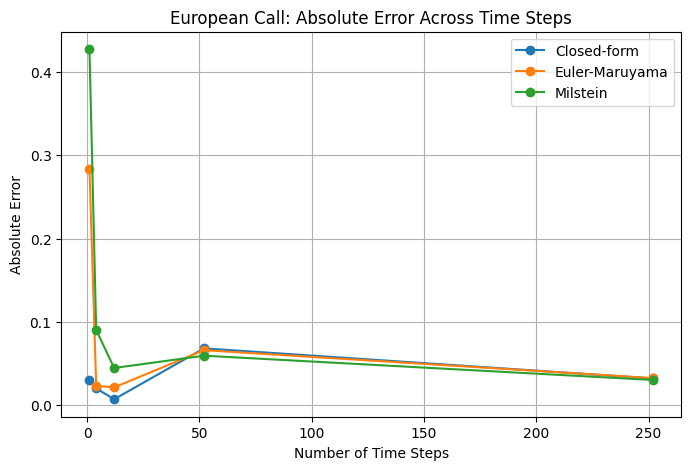

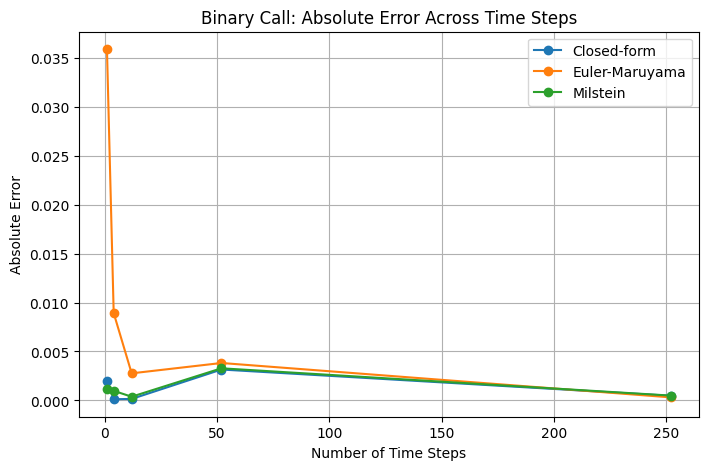

In [ ]:
# ==============================
# Plot absolute errors
# ==============================

import matplotlib.pyplot as plt

# Plot absolute errors for European call
plt.figure(figsize=(8, 5))

for scheme in european_error_pivot.columns:
    plt.plot(
        european_error_pivot.index,
        european_error_pivot[scheme],
        marker="o",
        label=scheme
    )

plt.xlabel("Number of Time Steps")
plt.ylabel("Absolute Error")
plt.title("European Call: Absolute Error Across Time Steps")
plt.legend()
plt.grid(True)
plt.show()


# Plot absolute errors for binary call
plt.figure(figsize=(8, 5))

for scheme in binary_error_pivot.columns:
    plt.plot(
        binary_error_pivot.index,
        binary_error_pivot[scheme],
        marker="o",
        label=scheme
    )

plt.xlabel("Number of Time Steps")
plt.ylabel("Absolute Error")
plt.title("Binary Call: Absolute Error Across Time Steps")
plt.legend()
plt.grid(True)
plt.show()

### Step 3 result discussion

The results show that all three simulation schemes produce option prices close to the analytical benchmarks when the number of paths is large. For very coarse time discretization, especially when \(n\_steps=1\), the Euler-Maruyama and Milstein schemes can show larger pricing errors because the time discretization is rough. As the number of time steps increases, the three schemes generally become closer to each other.

However, the absolute errors are not strictly decreasing as \(n\_steps\) increases. This is because the reported error includes both time-discretization error and Monte Carlo sampling error. Even the closed-form time-stepping scheme, which has no discretization error for GBM, still shows random deviations from the analytical price due to finite simulation paths. Therefore, the results should be interpreted as numerical evidence rather than a strictly monotonic convergence table.

For the binary call option, the error pattern is less smooth than that of the European call option. This is mainly because the binary payoff is discontinuous at the strike. A small change in the terminal stock price around \(K\) can change the payoff from 0 to 1, making the binary option more sensitive to simulation noise near the exercise boundary.


## Step 4. Parameter sensitivity analysis

In this step, the input parameters are changed one at a time to examine their impact on the European call and binary call option prices. The baseline parameters are

$$
S_0=100,\quad K=100,\quad T=1,\quad r=5\%,\quad \sigma=20\%.
$$

The parameters considered in this step are the initial stock price $S_0$, strike price $K$, volatility $\sigma$, risk-free rate $r$, and maturity $T$. For each parameter experiment, only one parameter is changed while the others are kept at their baseline values.

To focus on the economic impact of the parameters, the analytical price and the closed-form Monte Carlo price are reported. The closed-form GBM simulation is used because it avoids time-discretization error and therefore provides a cleaner comparison for parameter sensitivity.

### Course material connection

This step is mainly connected to Section 3.1, where the Black-Scholes formula shows how European option values depend on $S_0$, $K$, $r$, $\sigma$, and $T$. It is also related to Section 3.2, since option prices are interpreted as discounted risk-neutral expected payoffs. The Monte Carlo implementation is connected to Section 3.4 and the Python 9 Monte Carlo lab, where simulated stock prices are used to estimate option values.

In [ ]:
# ==============================
# Parameter sensitivity analysis
# ==============================

def closed_form_mc_price_for_parameters(
    S0_value, K_value, T_value, r_value, sigma_value,
    n_paths=100000, random_seed=123
):
    """
    Compute analytical prices and closed-form Monte Carlo prices
    for European call and binary call options under a given parameter set.
    """
    rng = np.random.default_rng(random_seed)
    Z = rng.standard_normal(n_paths)

    ST = S0_value * np.exp(
        (r_value - 0.5 * sigma_value**2) * T_value
        + sigma_value * np.sqrt(T_value) * Z
    )

    analytical_call_price = bs_european_call_price(
        S0_value, K_value, T_value, r_value, sigma_value
    )

    analytical_binary_price = bs_binary_call_price(
        S0_value, K_value, T_value, r_value, sigma_value
    )

    mc_call_price, mc_call_se = monte_carlo_price_from_terminal(
        ST=ST,
        K=K_value,
        T=T_value,
        r=r_value,
        option_type="european_call"
    )

    mc_binary_price, mc_binary_se = monte_carlo_price_from_terminal(
        ST=ST,
        K=K_value,
        T=T_value,
        r=r_value,
        option_type="binary_call",
        cash_payoff=1.0
    )

    return {
        "European Analytical Price": analytical_call_price,
        "European MC Price": mc_call_price,
        "European MC Standard Error": mc_call_se,
        "Binary Analytical Price": analytical_binary_price,
        "Binary MC Price": mc_binary_price,
        "Binary MC Standard Error": mc_binary_se
    }


def run_parameter_sensitivity(
    base_params, parameter_grid, n_paths=100000, random_seed=123
):
    """
    Change one parameter at a time and record option prices.
    """
    results = []

    for parameter_name, values in parameter_grid.items():
        for value in values:
            params = base_params.copy()
            params[parameter_name] = value

            price_result = closed_form_mc_price_for_parameters(
                S0_value=params["S0"],
                K_value=params["K"],
                T_value=params["T"],
                r_value=params["r"],
                sigma_value=params["sigma"],
                n_paths=n_paths,
                random_seed=random_seed
            )

            row = {
                "Changed Parameter": parameter_name,
                "Parameter Value": value,
                "S0": params["S0"],
                "K": params["K"],
                "T": params["T"],
                "r": params["r"],
                "sigma": params["sigma"]
            }

            row.update(price_result)
            results.append(row)

    return pd.DataFrame(results)


# Baseline parameter set
base_params = {
    "S0": S0,
    "K": K,
    "T": T,
    "r": r,
    "sigma": sigma
}

# Parameter values to test
parameter_grid = {
    "S0": [80, 90, 100, 110, 120],
    "K": [80, 90, 100, 110, 120],
    "sigma": [0.10, 0.20, 0.30, 0.40, 0.50],
    "r": [0.01, 0.03, 0.05, 0.07, 0.10],
    "T": [0.25, 0.50, 1.00, 2.00, 3.00]
}

sensitivity_results = run_parameter_sensitivity(
    base_params=base_params,
    parameter_grid=parameter_grid,
    n_paths=n_paths,
    random_seed=123
)

sensitivity_results

,Changed Parameter,Parameter Value,S0,K,T,r,sigma,European Analytical Price,European MC Price,European MC Standard Error,Binary Analytical Price,Binary MC Price,Binary MC Standard Error
0,S0,80.00,80,100,1.00,0.05,0.2,1.859420,1.867571,0.018648,0.158944,0.159740,0.001124
1,S0,90.00,90,100,1.00,0.05,0.2,5.091222,5.105116,0.032206,0.335936,0.335765,0.001438
2,S0,100.00,100,100,1.00,0.05,0.2,10.450584,10.457350,0.046635,0.532325,0.531927,0.001493
3,S0,110.00,110,100,1.00,0.05,0.2,17.662954,17.676248,0.059827,0.698700,0.699677,0.001327
4,S0,120.00,120,100,1.00,0.05,0.2,26.169044,26.195032,0.070950,0.814056,0.815051,0.001054
5,K,80.00,100,80,1.00,0.05,0.2,24.588835,24.612752,0.060621,0.853436,0.853671,0.000913
6,K,90.00,100,90,1.00,0.05,0.2,16.699448,16.712712,0.055051,0.714121,0.715705,0.001298
7,K,100.00,100,100,1.00,0.05,0.2,10.450584,10.457350,0.046635,0.532325,0.531927,0.001493
8,K,110.00,100,110,1.00,0.05,0.2,6.040088,6.055387,0.036872,0.353861,0.353553,0.001454
9,K,120.00,100,120,1.00,0.05,0.2,3.247477,3.263719,0.027486,0.212264,0.213028,0.001254


In [ ]:
# ==============================
# Clean sensitivity tables
# ==============================

european_sensitivity_table = sensitivity_results[
    ["Changed Parameter", "Parameter Value",
     "European Analytical Price", "European MC Price", "European MC Standard Error"]
].copy()

binary_sensitivity_table = sensitivity_results[
    ["Changed Parameter", "Parameter Value",
     "Binary Analytical Price", "Binary MC Price", "Binary MC Standard Error"]
].copy()

print("European Call - Parameter Sensitivity")
display(european_sensitivity_table)

print("Binary Call - Parameter Sensitivity")
display(binary_sensitivity_table)

European Call - Parameter Sensitivity


,Changed Parameter,Parameter Value,European Analytical Price,European MC Price,European MC Standard Error
0,S0,80.00,1.859420,1.867571,0.018648
1,S0,90.00,5.091222,5.105116,0.032206
2,S0,100.00,10.450584,10.457350,0.046635
3,S0,110.00,17.662954,17.676248,0.059827
4,S0,120.00,26.169044,26.195032,0.070950
5,K,80.00,24.588835,24.612752,0.060621
6,K,90.00,16.699448,16.712712,0.055051
7,K,100.00,10.450584,10.457350,0.046635
8,K,110.00,6.040088,6.055387,0.036872
9,K,120.00,3.247477,3.263719,0.027486


Binary Call - Parameter Sensitivity


,Changed Parameter,Parameter Value,Binary Analytical Price,Binary MC Price,Binary MC Standard Error
0,S0,80.00,0.158944,0.159740,0.001124
1,S0,90.00,0.335936,0.335765,0.001438
2,S0,100.00,0.532325,0.531927,0.001493
3,S0,110.00,0.698700,0.699677,0.001327
4,S0,120.00,0.814056,0.815051,0.001054
5,K,80.00,0.853436,0.853671,0.000913
6,K,90.00,0.714121,0.715705,0.001298
7,K,100.00,0.532325,0.531927,0.001493
8,K,110.00,0.353861,0.353553,0.001454
9,K,120.00,0.212264,0.213028,0.001254


In [ ]:
# ==============================
# Pivot tables for analytical prices
# ==============================

european_sensitivity_pivot = european_sensitivity_table.pivot(
    index="Parameter Value",
    columns="Changed Parameter",
    values="European Analytical Price"
)

binary_sensitivity_pivot = binary_sensitivity_table.pivot(
    index="Parameter Value",
    columns="Changed Parameter",
    values="Binary Analytical Price"
)

print("European Call - Analytical Price Sensitivity Pivot Table")
display(european_sensitivity_pivot)

print("Binary Call - Analytical Price Sensitivity Pivot Table")
display(binary_sensitivity_pivot)

European Call - Analytical Price Sensitivity Pivot Table


Changed Parameter,K,S0,T,r,sigma
Parameter Value,,,,,
0.01,NaN,NaN,NaN,8.433319,NaN
0.03,NaN,NaN,NaN,9.413403,NaN
0.05,NaN,NaN,NaN,10.450584,NaN
0.07,NaN,NaN,NaN,11.541470,NaN
0.10,NaN,NaN,NaN,13.269677,6.804958
0.20,NaN,NaN,NaN,NaN,10.450584
0.25,NaN,NaN,4.614997,NaN,NaN
0.30,NaN,NaN,NaN,NaN,14.231255
0.40,NaN,NaN,NaN,NaN,18.022951


Binary Call - Analytical Price Sensitivity Pivot Table


Changed Parameter,K,S0,T,r,sigma
Parameter Value,,,,,
0.01,NaN,NaN,NaN,0.475285,NaN
0.03,NaN,NaN,NaN,0.504572,NaN
0.05,NaN,NaN,NaN,0.532325,NaN
0.07,NaN,NaN,NaN,0.558230,NaN
0.10,NaN,NaN,NaN,0.593050,0.640791
0.20,NaN,NaN,NaN,NaN,0.532325
0.25,NaN,NaN,0.523310,NaN,NaN
0.30,NaN,NaN,NaN,NaN,0.481939
0.40,NaN,NaN,NaN,NaN,0.447180


Note: The pivot tables above are used only as a compact display of analytical prices across different parameter experiments. The NaN entries occur because different parameters have different value ranges and units. They do not indicate missing pricing results; the full sensitivity results are reported in the long tables above.

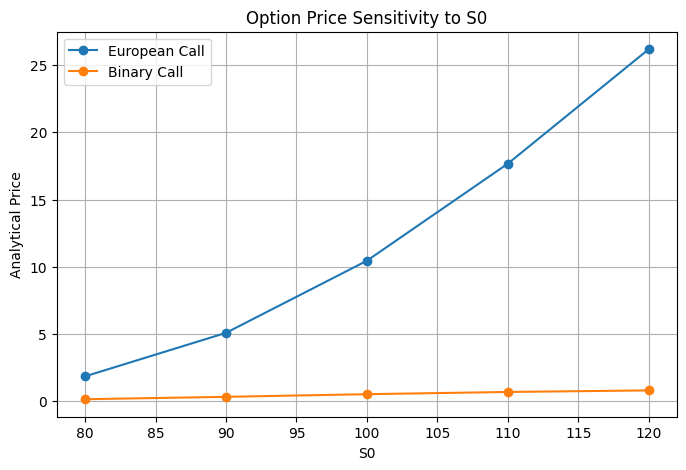

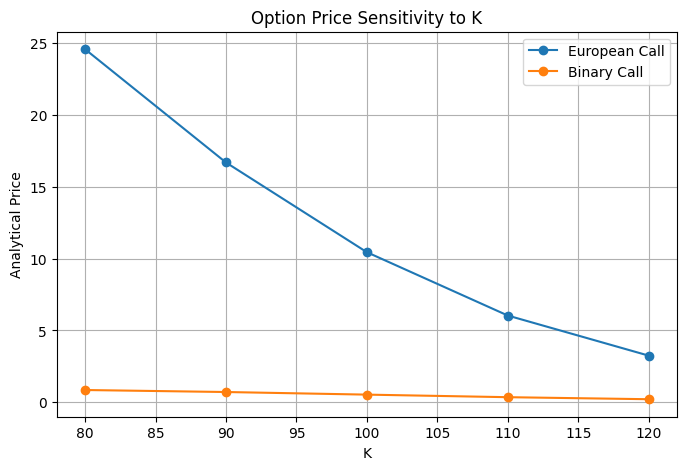

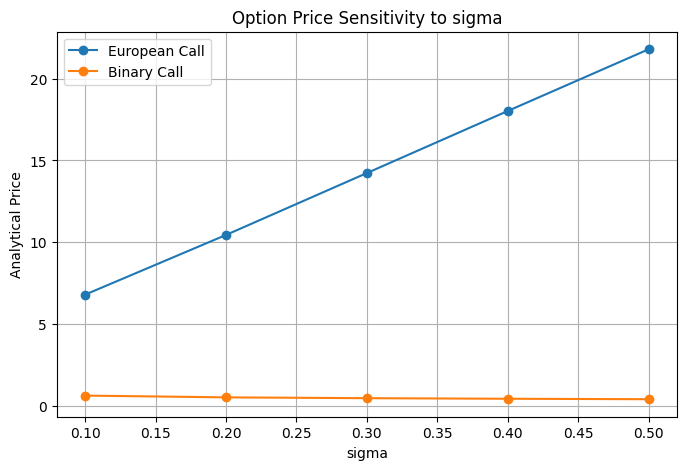

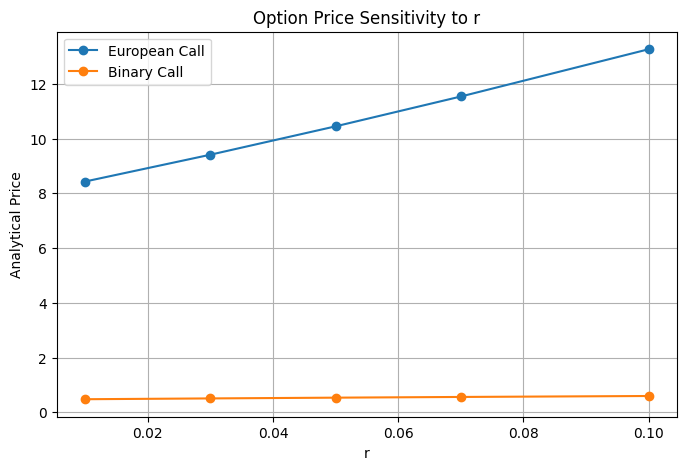

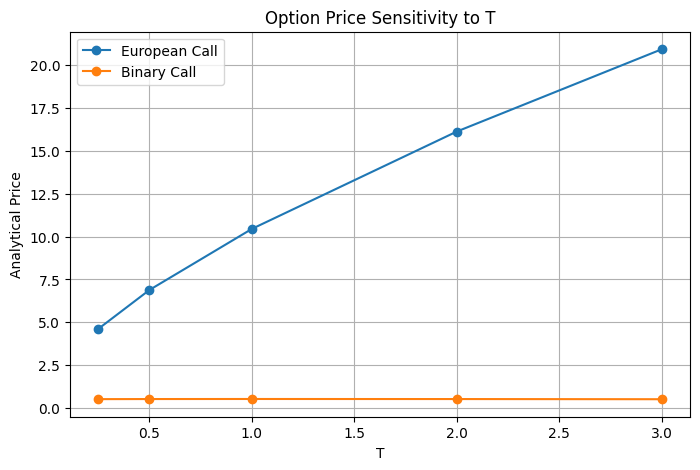

In [ ]:
# ==============================
# Plot parameter sensitivity
# ==============================

import matplotlib.pyplot as plt

def plot_parameter_sensitivity(sensitivity_results, parameter_name):
    """
    Plot analytical prices of European call and binary call
    against a selected parameter.
    """
    subset = sensitivity_results[
        sensitivity_results["Changed Parameter"] == parameter_name
    ].copy()

    plt.figure(figsize=(8, 5))

    plt.plot(
        subset["Parameter Value"],
        subset["European Analytical Price"],
        marker="o",
        label="European Call"
    )

    plt.plot(
        subset["Parameter Value"],
        subset["Binary Analytical Price"],
        marker="o",
        label="Binary Call"
    )

    plt.xlabel(parameter_name)
    plt.ylabel("Analytical Price")
    plt.title(f"Option Price Sensitivity to {parameter_name}")
    plt.legend()
    plt.grid(True)
    plt.show()


# Plot sensitivity for each parameter
for parameter_name in parameter_grid.keys():
    plot_parameter_sensitivity(sensitivity_results, parameter_name)

### Step 4 result discussion

The parameter sensitivity results are consistent with the standard economic intuition of option pricing. For the European call option, the price increases as the initial stock price $S_0$ increases and decreases as the strike price $K$ increases. This reflects the fact that a higher current stock price makes the call option more likely to finish in the money, while a higher strike makes exercise less attractive.

The European call price also increases with volatility $\sigma$. This is consistent with the positive vega of a long option position: higher volatility increases the probability of large favourable movements, while the downside of the option holder is limited. The call price also increases with the risk-free rate $r$ and with maturity $T$ in this parameter range.

The binary call option behaves differently from the European call option in some cases. Since its payoff is fixed at 1 if $S_T>K$ and 0 otherwise, it depends mainly on the risk-neutral probability of finishing in the money rather than on the magnitude by which the stock price exceeds the strike. As a result, its sensitivity to volatility and maturity can be less intuitive than that of the European call option.

The Monte Carlo prices are close to the analytical prices across the parameter experiments, and the differences are generally small relative to the reported Monte Carlo standard errors.

## Step 5. Antithetic variates for variance reduction


In this step, the antithetic variates technique is used to reduce the variance of the Monte Carlo estimator. Instead of simulating only independent standard normal random variables \(Z\), antithetic simulation uses paired random numbers:

$$
Z \quad \text{and} \quad -Z.
$$

Both \(Z\) and \(-Z\) follow the same standard normal distribution, but they are negatively correlated. For a monotonic payoff, the two corresponding payoffs often move in opposite directions, which can reduce the variance of the average payoff.

For each random draw \(Z_i\), two terminal stock prices are generated:

$$
S_T^{+}
=
S_0 \exp\left[
\left(r-\frac{1}{2}\sigma^2\right)T+\sigma\sqrt{T}Z_i
\right],
$$

and

$$
S_T^{-}
=
S_0 \exp\left[
\left(r-\frac{1}{2}\sigma^2\right)T-\sigma\sqrt{T}Z_i
\right].
$$

The paired payoff average is then used as the simulation unit. For example, for a European call option,

$$
\bar{P}_i
=
\frac{1}{2}
\left[
\max(S_T^{+}-K,0)
+
\max(S_T^{-}-K,0)
\right].
$$

The antithetic Monte Carlo estimator is the discounted average of these paired payoffs.


### Course material connection

This step is mainly connected to T5, where antithetic variates are introduced as a variance reduction technique for Monte Carlo simulation. It is also related to the Python 9 Monte Carlo lab, which discusses variance reduction methods such as antithetic variates and moment matching. The general Monte Carlo pricing framework comes from Section 3.4, while the risk-neutral discounted expectation comes from Section 3.2.

In [ ]:
# ==============================
# Antithetic variates
# ==============================

def standard_mc_closed_form(S0, K, T, r, sigma, n_paths, option_type, random_seed=42):
    """
    Standard Monte Carlo pricing using independent normal random variables.
    """
    rng = np.random.default_rng(random_seed)
    Z = rng.standard_normal(n_paths)

    ST = S0 * np.exp(
        (r - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * Z
    )

    if option_type == "european_call":
        payoff = np.maximum(ST - K, 0)
    elif option_type == "binary_call":
        payoff = (ST > K).astype(float)
    else:
        raise ValueError("option_type must be 'european_call' or 'binary_call'")

    discount_factor = np.exp(-r * T)
    price = discount_factor * np.mean(payoff)
    standard_error = discount_factor * np.std(payoff, ddof=1) / np.sqrt(n_paths)

    return price, standard_error


def antithetic_mc_closed_form(S0, K, T, r, sigma, n_pairs, option_type, random_seed=42):
    """
    Antithetic Monte Carlo pricing using paired normal random variables Z and -Z.

    The standard error is computed from paired payoff averages.
    """
    rng = np.random.default_rng(random_seed)
    Z = rng.standard_normal(n_pairs)

    ST_plus = S0 * np.exp(
        (r - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * Z
    )

    ST_minus = S0 * np.exp(
        (r - 0.5 * sigma**2) * T
        - sigma * np.sqrt(T) * Z
    )

    if option_type == "european_call":
        payoff_plus = np.maximum(ST_plus - K, 0)
        payoff_minus = np.maximum(ST_minus - K, 0)
    elif option_type == "binary_call":
        payoff_plus = (ST_plus > K).astype(float)
        payoff_minus = (ST_minus > K).astype(float)
    else:
        raise ValueError("option_type must be 'european_call' or 'binary_call'")

    paired_payoff = 0.5 * (payoff_plus + payoff_minus)

    discount_factor = np.exp(-r * T)
    price = discount_factor * np.mean(paired_payoff)
    standard_error = discount_factor * np.std(paired_payoff, ddof=1) / np.sqrt(n_pairs)

    return price, standard_error


def compare_standard_and_antithetic(S0, K, T, r, sigma, n_pairs, random_seed=42):
    """
    Compare standard Monte Carlo and antithetic Monte Carlo
    using the same total number of simulated terminal stock prices.

    Standard MC uses 2*n_pairs independent paths.
    Antithetic MC uses n_pairs pairs, also resulting in 2*n_pairs stock prices.
    """
    total_paths = 2 * n_pairs

    results = []

    for option_type, option_name, analytical_price in [
        ("european_call", "European Call", analytical_call),
        ("binary_call", "Binary Call", analytical_binary)
    ]:
        standard_price, standard_se = standard_mc_closed_form(
            S0=S0,
            K=K,
            T=T,
            r=r,
            sigma=sigma,
            n_paths=total_paths,
            option_type=option_type,
            random_seed=random_seed
        )

        antithetic_price, antithetic_se = antithetic_mc_closed_form(
            S0=S0,
            K=K,
            T=T,
            r=r,
            sigma=sigma,
            n_pairs=n_pairs,
            option_type=option_type,
            random_seed=random_seed
        )

        variance_reduction_ratio = (standard_se / antithetic_se) ** 2

        results.append({
            "Option": option_name,
            "Method": "Standard MC",
            "Number of Stock Prices": total_paths,
            "MC Price": standard_price,
            "Analytical Price": analytical_price,
            "MC Standard Error": standard_se,
            "MC Error": standard_price - analytical_price,
            "Absolute Error": abs(standard_price - analytical_price),
            "Variance Reduction Ratio": np.nan
        })

        results.append({
            "Option": option_name,
            "Method": "Antithetic MC",
            "Number of Stock Prices": total_paths,
            "MC Price": antithetic_price,
            "Analytical Price": analytical_price,
            "MC Standard Error": antithetic_se,
            "MC Error": antithetic_price - analytical_price,
            "Absolute Error": abs(antithetic_price - analytical_price),
            "Variance Reduction Ratio": variance_reduction_ratio
        })

    return pd.DataFrame(results)


# Use the same total number of stock prices as before
n_pairs = 50000

antithetic_comparison = compare_standard_and_antithetic(
    S0=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigma,
    n_pairs=n_pairs,
    random_seed=42
)

antithetic_comparison

,Option,Method,Number of Stock Prices,MC Price,Analytical Price,MC Standard Error,MC Error,Absolute Error,Variance Reduction Ratio
0,European Call,Standard MC,100000,10.420541,10.450584,0.046770,-0.030042,0.030042,NaN
1,European Call,Antithetic MC,100000,10.467314,10.450584,0.033077,0.016731,0.016731,1.999327
2,Binary Call,Standard MC,100000,0.530310,0.532325,0.001494,-0.002014,0.002014,NaN
3,Binary Call,Antithetic MC,100000,0.533193,0.532325,0.000694,0.000868,0.000868,4.636859


In [ ]:
# ==============================
# Repeated experiments
# ==============================

def repeated_antithetic_experiments(S0, K, T, r, sigma, n_pairs, seed_list):
    """
    Repeat standard and antithetic Monte Carlo experiments across different seeds.
    """
    all_results = []

    for seed in seed_list:
        result = compare_standard_and_antithetic(
            S0=S0,
            K=K,
            T=T,
            r=r,
            sigma=sigma,
            n_pairs=n_pairs,
            random_seed=seed
        )
        result["Seed"] = seed
        all_results.append(result)

    return pd.concat(all_results, ignore_index=True)


seed_list = list(range(1, 11))

repeated_antithetic_results = repeated_antithetic_experiments(
    S0=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigma,
    n_pairs=n_pairs,
    seed_list=seed_list
)

repeated_antithetic_results

,Option,Method,Number of Stock Prices,MC Price,Analytical Price,MC Standard Error,MC Error,Absolute Error,Variance Reduction Ratio,Seed
0,European Call,Standard MC,100000,10.357758,10.450584,0.046422,-0.092826,0.092826,NaN,1
1,European Call,Antithetic MC,100000,10.401422,10.450584,0.032810,-0.049162,0.049162,2.001858,1
2,Binary Call,Standard MC,100000,0.530767,0.532325,0.001494,-0.001558,0.001558,NaN,1
3,Binary Call,Antithetic MC,100000,0.531880,0.532325,0.000687,-0.000445,0.000445,4.729123,1
4,European Call,Standard MC,100000,10.418774,10.450584,0.046436,-0.031809,0.031809,NaN,2
5,European Call,Antithetic MC,100000,10.420068,10.450584,0.032885,-0.030516,0.030516,1.993920,2
6,Binary Call,Standard MC,100000,0.531956,0.532325,0.001493,-0.000369,0.000369,NaN,2
7,Binary Call,Antithetic MC,100000,0.532251,0.532325,0.000689,-0.000074,0.000074,4.699513,2
8,European Call,Standard MC,100000,10.455052,10.450584,0.046512,0.004468,0.004468,NaN,3
9,European Call,Antithetic MC,100000,10.421161,10.450584,0.032636,-0.029423,0.029423,2.031213,3


In [ ]:
# ==============================
# Summary of repeated experiments
# ==============================

antithetic_summary = repeated_antithetic_results.groupby(
    ["Option", "Method"]
).agg(
    Average_MC_Price=("MC Price", "mean"),
    Average_Standard_Error=("MC Standard Error", "mean"),
    Average_Absolute_Error=("Absolute Error", "mean")
).reset_index()

antithetic_summary

,Option,Method,Average_MC_Price,Average_Standard_Error,Average_Absolute_Error
0,Binary Call,Antithetic MC,0.532715,0.000691,0.000640
1,Binary Call,Standard MC,0.532427,0.001493,0.000691
2,European Call,Antithetic MC,10.439644,0.032840,0.028809
3,European Call,Standard MC,10.446468,0.046549,0.032428


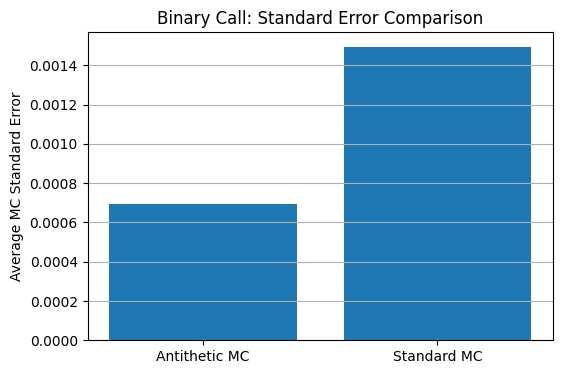

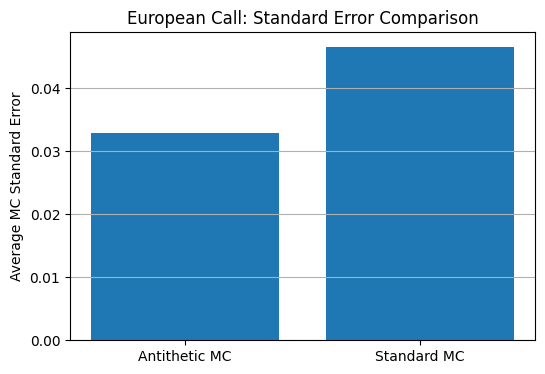

In [ ]:
# ==============================
# Step 5.3: Plot standard error comparison
# ==============================

import matplotlib.pyplot as plt

for option_name in antithetic_summary["Option"].unique():
    subset = antithetic_summary[antithetic_summary["Option"] == option_name]

    plt.figure(figsize=(6, 4))
    plt.bar(
        subset["Method"],
        subset["Average_Standard_Error"]
    )
    plt.ylabel("Average MC Standard Error")
    plt.title(f"{option_name}: Standard Error Comparison")
    plt.grid(axis="y")
    plt.show()

### Step 5 result discussion

The antithetic variates method reduces the Monte Carlo standard error for both the European call option and the binary call option. For the European call option, the repeated experiments show that the average standard error decreases from approximately 0.0465 under standard Monte Carlo to approximately 0.0328 under antithetic Monte Carlo. This corresponds to a variance reduction ratio close to 2 in the single-run comparison.

For the binary call option, the variance reduction effect is even stronger in this experiment. The average standard error decreases from approximately 0.00149 to approximately 0.00069, and the variance reduction ratio is around 4.6. This suggests that the paired paths generated by \(Z\) and \(-Z\) create strong negative dependence in the binary payoff under the current at-the-money parameter setting.

It is important to note that variance reduction does not guarantee a smaller absolute pricing error in every single simulation. The absolute error still depends on the realized random samples. The main benefit of antithetic variates is that it lowers the variance and standard error of the Monte Carlo estimator, making the simulation result more stable on average.


## Interesting observations and problems encountered

Several observations arise from the numerical experiments. First, the closed-form time-stepping scheme provides a useful benchmark for Monte Carlo simulation of the geometric Brownian motion, because it has no time-discretization error under the constant-parameter Black-Scholes setting. However, even this scheme still produces random deviations from the analytical price due to finite Monte Carlo sampling.

Second, the Euler-Maruyama and Milstein schemes become closer to the closed-form simulation as the number of time steps increases. However, the pricing error does not decrease monotonically with the number of time steps, because the observed error combines both time-discretization error and Monte Carlo sampling error.

Third, the binary call option is more sensitive to simulation noise near the strike. This is due to its discontinuous payoff. A very small change in the terminal stock price around \(K\) can change the payoff from 0 to 1. Therefore, the error pattern for the binary call option can be less smooth than that of the European call option.

Fourth, antithetic variates reduce the standard error of the Monte Carlo estimator. The effect is visible for both the European call and binary call options. Nevertheless, the technique does not guarantee a smaller absolute error in every individual run; its main benefit is variance reduction on average.



## Conclusion

This project demonstrates how Monte Carlo simulation can be used to price European call and binary call options under the risk-neutral Black-Scholes framework. The analytical Black-Scholes prices provide useful benchmarks for evaluating simulation accuracy.

The closed-form time-stepping scheme is the most accurate way to simulate the terminal stock price under the constant-parameter GBM assumption, since it exactly matches the lognormal distribution of $S_T$. Euler-Maruyama and Milstein are more general numerical schemes for SDE simulation. In the GBM case, Milstein includes an additional correction term and can improve the approximation relative to Euler-Maruyama, especially when the time step is coarse.

The parameter sensitivity analysis confirms standard option pricing intuition. The European call price increases with $S_0$, $\sigma$, $r$, and $T$, and decreases with $K$. The binary call option behaves differently in some cases because its payoff depends only on whether $S_T$ exceeds $K$, not by how much.

Finally, antithetic variates are effective in reducing Monte Carlo standard errors. This confirms that variance reduction techniques can improve simulation efficiency without changing the underlying pricing model.